In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 1.1.1 What is a time Series
* sequence of data from a atural or social process, observed over time
* always start with diagnostic plots, with time on x, target on y to get started
* time series is a discrete stochastic process

#### 1.1.3 Objective of Time Series
* deterministic trends
* deterministic seasonality
* dramatic change in its behaviour pattern
* outliers and/or anomalies
* forecasting
* signal detection and estimation

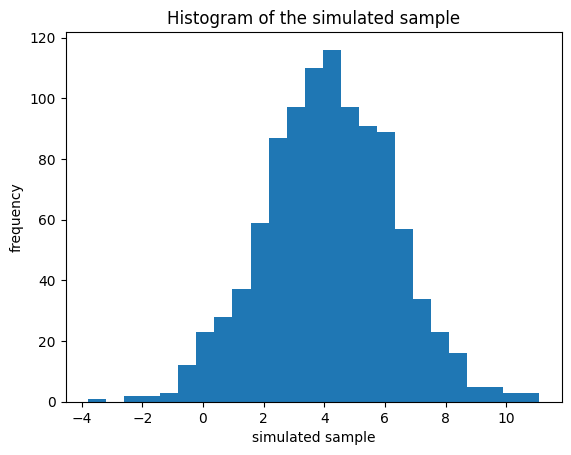

In [7]:
np.random.seed(135)
x = np.random.normal(loc=4.1, scale=2.2, size=1000)
h_fig = plt.hist(x, bins=25)
plt.xlabel('simulated sample')
plt.ylabel('frequency')
plt.title('Histogram of the simulated sample')
plt.show()

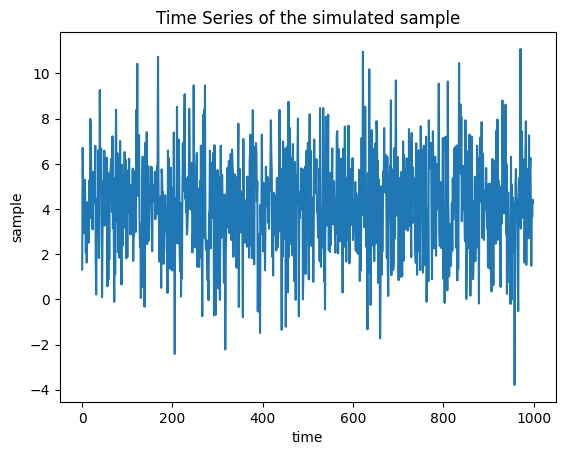

In [10]:
xts = pd.Series(x)
xts.plot()
plt.xlabel('time')
plt.ylabel('sample')
plt.title('Time Series of the simulated sample')
plt.show()

### Time Series Moment Functions and Stationarity

#### 1.3.1 Moments
In order to completely describe the probabilistic structure of a time series (Xt), its finite dimensional distribution family has to be givenm for any positive integer n, and at time points t1, ... tn. This is very difficult to compute in practice, instead moments can be used to convey a lot of the information
1. Mean function
2. Standard deviance
3. Autocovariance (Cov(Xs, Xt))
4. Autocorrelation (Corr(Xs, Xt))
    * <= 1

#### 1.3.2 Stationarity and Ergodicity

Stricly stationary - for any n, any subset of size n of datapoints has the same joint distribution
Weak Stationarity
1. E(Xt) = mu constant
2. E(Xt^2) < inf
3. Cov(Xt, Xt+k) is independent of t, for all k

Ergodicity:
* mean ergodic if lim n-> inf E(1/n(sum_i=1^n(Xt-mu)^2) = 0
* Variance ergodic similar defn
* Ergodic if both mean and variacne ergodic

Ergodic means give sufficiently long sample of a stationary time series, can estimate mu and sigma^2 by using a sufficiently long sample

In practice, need to estimate these from sample data. (1) If a time series plot clearly shows a trend/seasonlaity, it is surely nonstationary. (2) If the ACF r_k very slowly or hardly tapers off as the lag k increases, time series should also be non stationary.

* to compute the ACF for (x_n, x_(n+k)), observe all these pairs. Less data for large k, so would expect this to drop off

Text(0.5, 1.0, 'Chinese Quarterly GDP')

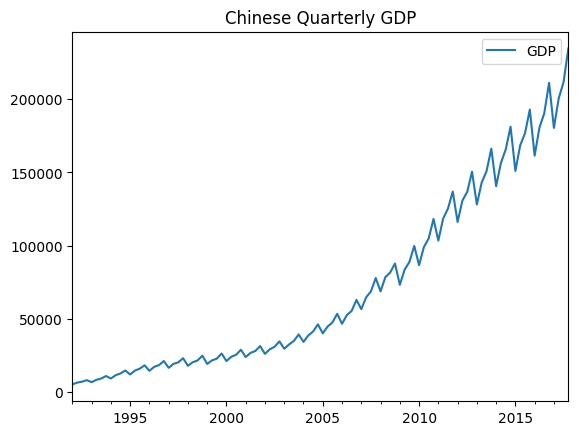

In [8]:
from PythonTsa.datadir import getdtapath
dtapath = getdtapath()
x=pd.read_csv(dtapath + "gdpquarterlychina1992.1-2017.4.csv",header=0)
dates = pd.date_range(start = '1992', periods=len(x), freq='QE')
x.index = dates

x.plot()
plt.title('Chinese Quarterly GDP')

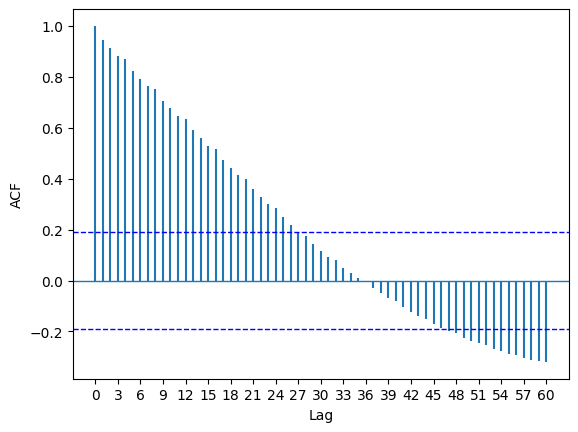

In [10]:
from PythonTsa.plot_acf_pacf import acf_pacf_fig
acf_pacf_fig(x, both=False, lag=60)

<Axes: >

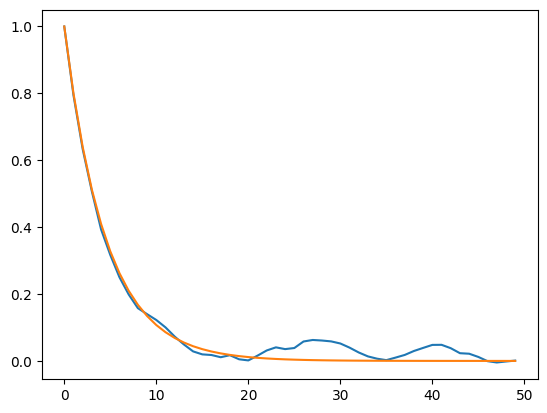

In [8]:
def compute_acf(x, lag):
    # sample ACF = gamma_k / gamma_0
    # assuming x is an input pd series

    x_lag = x.shift(lag)
    mu = np.mean(x)
    n = len(x)

    res = pd.DataFrame({'Feature': x, 'Lag': x_lag})
    res['acv_unit'] = (res['Feature'] - mu) * (res['Lag'] - mu)
    res['var_unit'] = (res['Feature'] - mu)**2

    acv = res['acv_unit'].sum() / n
    var = res['var_unit'].sum() / n

    return acv / var


def generate_ar1(n, phi, sigma=1, seed=42):

    np.random.seed(seed)
    x = np.zeros(n)
    eps = np.random.normal(0, sigma, n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + eps[t]
    return pd.Series(x)

phi = 0.8
x = generate_ar1(n=2000, phi=phi)
res = []
theoretical = []
for i in range(50):
    res.append(compute_acf(x, lag=i))
    theoretical.append(phi**i)


res = pd.Series(res)
theoretical = pd.Series(theoretical)
res.plot()
theoretical.plot()

#### Random Walk

$X_t = X_{t-1} + W_t$, where $W_t$ is white noise

E(Xt) = E(X0) is a constant

Var(X_t) = Var(X_{t-1}) + sigma_w^2) > Var(X_{t-1})


#### Log Random Walk

Time series data is very non - stationary, and the same is true when taking the logarithm. However Let Y_t = log(X_t) - log(X_{t-1}), the first difference. This can make financial time series data appear stationary / like white noise.

If $P_t$ is the closing price at time t, for a certain financial product. Return is $R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$. when x is small, log(1+x) ~ x, so this then becomes $log(P_t) - log(P_{t-1})$, so if we let $Z_t = log(P_t)$, then $Z_t \sim Z_{t-1} + R_t$, where $R_t$ is the return. Hence we see that the log return generally behaves like white noise

### Problems

In [17]:
# 1.1 - A time series is a series of observations of a target variable, indexed by time t. Everything in daily life can be considered a time series, as time is always evolving. For example, pen ink usage, food consumption, gas prices.


from PythonTsa.datadir import getdtapath
import os
dtapath = getdtapath()
datasets = os.listdir(dtapath)

data2 = pd.read_excel(f"{dtapath}/BitcoinPrice17-6-23-18-6-22.xlsx")
print(data2)

      Time  ClosingP   OpenP     High      Low  Volume    Rate
0    42909    2674.9  2672.8  2725.30  2652.80   8.14K  0.0008
1    42910    2502.6  2674.9  2700.00  2454.10  16.77K -0.0644
2    42911    2477.7  2502.6  2595.00  2369.10  18.13K -0.0099
3    42912    2394.6  2480.0  2510.40  2258.70  36.37K -0.0335
4    42913    2521.2  2393.5  2524.00  2208.10  33.49K  0.0529
..     ...       ...     ...      ...      ...     ...     ...
360  43269    6709.2  6443.5  6826.79  6378.60  26.37K  0.0425
361  43270    6737.5  6711.6  6832.90  6666.20  17.38K  0.0042
362  43271    6760.4  6732.7  6818.20  6560.00  18.71K  0.0034
363  43272    6713.5  6760.0  6787.10  6680.10  10.65K -0.0069
364  43273    6042.6  6715.2  6730.70  5929.12  55.25K -0.0999

[365 rows x 7 columns]


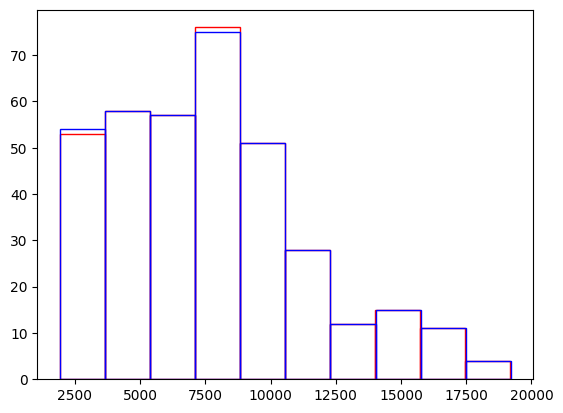

Text(0.5, 1.0, 'BTC closing prices')

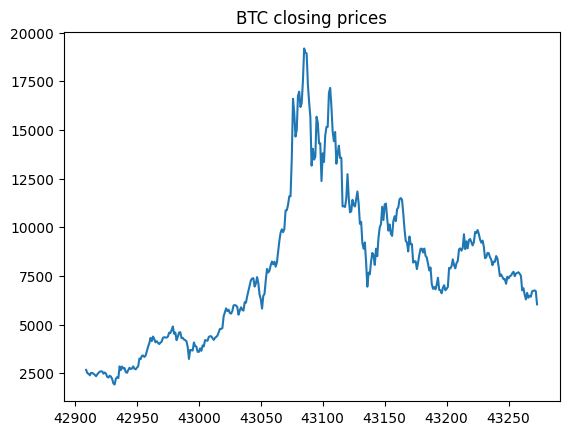

In [33]:
plt.hist(data2['ClosingP'], facecolor = 'none', edgecolor = 'red')
plt.hist(data2['OpenP'], facecolor = 'none', edgecolor = 'blue')
plt.show()


# dates = pd.date_range(start = '2017/06/23', periods=len(x), freq='QE')
# data2.index = dates

plt.plot(data2['Time'], data2['ClosingP'])
plt.title('BTC closing prices')

/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_90208/797132852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['OpenP_lag'] = data2['OpenP'].shift(1)
/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_90208/797132852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['OpenP_diff'] = data2['OpenP'] - data2['OpenP_lag']


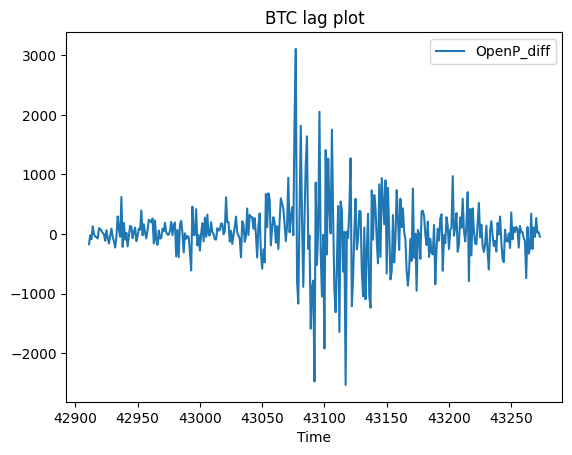

/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_90208/797132852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['OpenP_logdiff'] = np.log(data2['OpenP']) - np.log(data2['OpenP_lag'])


Text(0.5, 1.0, 'log diff BTC lag plot')

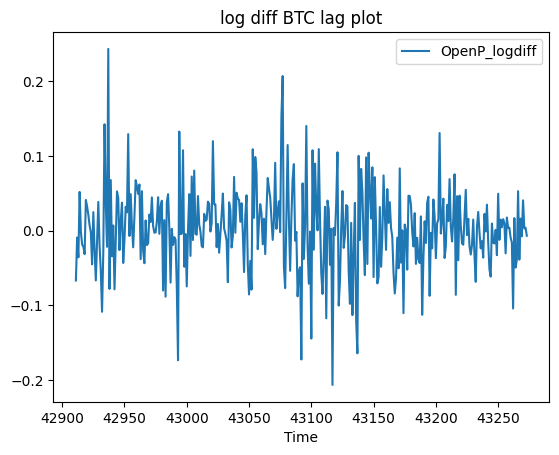

In [60]:
# BTC time series lag plot
data2['OpenP_lag'] = data2['OpenP'].shift(1)
data2['OpenP_diff'] = data2['OpenP'] - data2['OpenP_lag']
data2.plot('Time', 'OpenP_diff')
plt.title('BTC lag plot')
plt.show()

data2['OpenP_logdiff'] = np.log(data2['OpenP']) - np.log(data2['OpenP_lag'])
data2.plot('Time', 'OpenP_logdiff')
plt.title('log diff BTC lag plot')

log difference seems to be purely random noise. log Returns on each day are random.

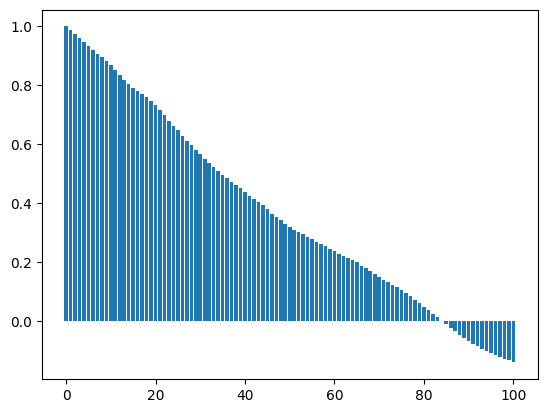

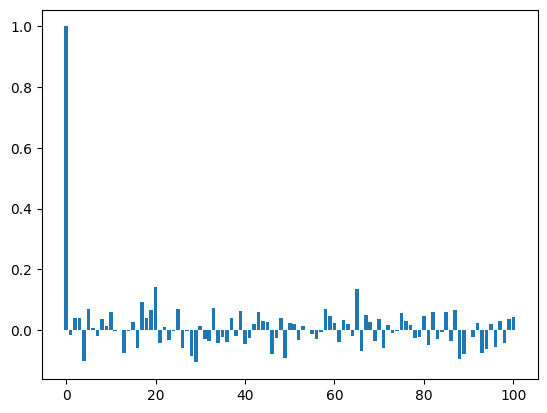

In [61]:
from statsmodels.tsa.stattools import acf
import seaborn as sns

acf_values = acf(data2['OpenP'], nlags=100)
plt.bar(range(len(acf_values)), acf_values)
plt.show()

idx = data2['OpenP_logdiff'].isnull()
data2 = data2[~idx]

acf_values = acf(data2['OpenP_logdiff'], nlags=100)
plt.bar(range(len(acf_values)), acf_values)
plt.show()


we can see that the plot of the open prices is highly non stationary, however when looking at the log returns, again appears as white noise

**skipping non computing exercises**

**1.9**

Mean stationary, but not variance stationary: Simple random walk. Mean 0, variance is growing

$X_n = X_{n-1} + e$

Variance Stationary, but not mean stationary

$x_t = t + e$